# Business Case 1 — Risk-Based Patient Engagement

## Business Objective

Identify patients who are more likely to miss their medical appointments and use the predicted risk to support targeted patient engagement.

The objective is to prioritize:
- Standard reminders for low-risk appointments
- SMS reminders and confirmation for medium-risk appointments
- Priority SMS reminders and alternative scheduling options for high-risk appointments

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df_business = pd.read_csv("../../data/Medical_appointment_data.csv")

print("Dataset shape:", df_business.shape)

Dataset shape: (109593, 26)


In [13]:
# Create a working copy
df = df_business.copy()

# Convert appointment date to datetime
df['appointment_date_continuous'] = pd.to_datetime(
    df['appointment_date_continuous'],
    errors='coerce'
)

# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing categorical values
for col in ['specialty', 'disability', 'place']:
    df[col] = df[col].fillna('Unknown')

# Preserve missing age information
df['age_missing'] = df['age'].isna().astype(int)

# Fill missing age with median
df['age'] = df['age'].fillna(df['age'].median())

# Fill missing weather values
weather_cols = [
    'average_temp_day',
    'average_rain_day',
    'max_temp_day',
    'max_rain_day'
]

for col in weather_cols:
    df[col] = df[col].fillna(df[col].median())

print("Cleaned dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

Cleaned dataset shape: (109557, 27)
Duplicate rows: 0


In [14]:
# Create features used by the trained model

df['appointment_year'] = df['appointment_date_continuous'].dt.year
df['appointment_month'] = df['appointment_date_continuous'].dt.month
df['appointment_dayofweek'] = df['appointment_date_continuous'].dt.dayofweek
df['appointment_day'] = df['appointment_date_continuous'].dt.day

# Weekend indicator
df['is_weekend'] = (
    df['appointment_dayofweek'] >= 5
).astype(int)

# Time of day
df['time_of_day'] = pd.cut(
    df['appointment_time'],
    bins=[6, 11, 14, 18],
    labels=['Morning', 'Afternoon', 'Evening']
)

# Age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 12, 18, 30, 45, 60, 120],
    labels=[
        'Under 12',
        '13-18',
        '19-30',
        '31-45',
        '46-60',
        'Over 60'
    ],
    include_lowest=True
)

print("Feature engineering completed.")
print("Dataset shape:", df.shape)

Feature engineering completed.
Dataset shape: (109557, 34)


In [15]:
import joblib

# Load the trained model and preprocessor
model = joblib.load("../../medical_no_show_model.pkl")
preprocessor = joblib.load("../../medical_no_show_preprocessor.pkl")

print("Model and preprocessor loaded successfully.")

Model and preprocessor loaded successfully.


In [16]:
# Prepare the features for prediction

X_business = df.drop(columns=['no_show'])

# Remove columns that were not used during model training
X_business = X_business.drop(
    columns=['appointment_date_continuous', 'place'],
    errors='ignore'
)

print("Prediction feature shape:", X_business.shape)

Prediction feature shape: (109557, 31)


In [17]:
# Transform the data using the trained preprocessor
X_business_processed = preprocessor.transform(X_business)

# Generate no-show probability
df['no_show_probability'] = model.predict_proba(
    X_business_processed
)[:, 1]

print("Probability generation completed.")
print(df['no_show_probability'].describe())

Probability generation completed.
count    109557.000000
mean          0.474256
std           0.141437
min           0.145860
25%           0.371870
50%           0.439463
75%           0.559939
max           0.880735
Name: no_show_probability, dtype: float64


In [18]:
# Create business-defined risk groups

df['risk_group'] = pd.cut(
    df['no_show_probability'],
    bins=[0, 0.30, 0.60, 1.00],
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
    include_lowest=True
)

# Count appointments in each risk group
risk_counts = df['risk_group'].value_counts().reindex(
    ['Low Risk', 'Medium Risk', 'High Risk']
)

print("Appointments by risk group:")
print(risk_counts)

Appointments by risk group:
risk_group
Low Risk        7449
Medium Risk    79912
High Risk      22196
Name: count, dtype: int64


In [19]:
# Convert no_show to numeric for validation

df['no_show_numeric'] = df['no_show'].map({
    'no': 0,
    'yes': 1
})

# Calculate actual no-show rate for each predicted risk group
risk_validation = df.groupby(
    'risk_group',
    observed=False
).agg(
    Appointments=('no_show_numeric', 'count'),
    No_Shows=('no_show_numeric', 'sum'),
    Actual_No_Show_Rate=('no_show_numeric', 'mean')
).reset_index()

# Convert rate to percentage
risk_validation['Actual_No_Show_Rate'] = (
    risk_validation['Actual_No_Show_Rate'] * 100
).round(2)

print(risk_validation)

    risk_group  Appointments  No_Shows  Actual_No_Show_Rate
0     Low Risk          7449       318                 4.27
1  Medium Risk         79912     20423                25.56
2    High Risk         22196     14090                63.48


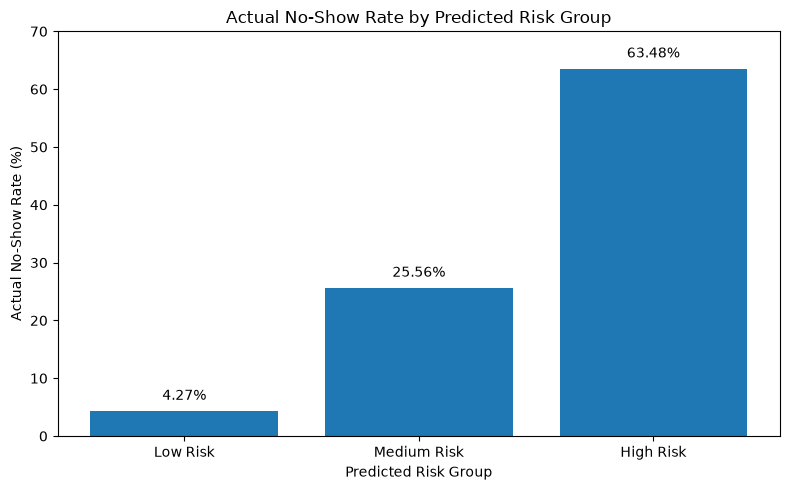

In [20]:
# Visualize actual no-show rate by predicted risk group

plt.figure(figsize=(8, 5))

plt.bar(
    risk_validation['risk_group'].astype(str),
    risk_validation['Actual_No_Show_Rate']
)

plt.xlabel('Predicted Risk Group')
plt.ylabel('Actual No-Show Rate (%)')
plt.title('Actual No-Show Rate by Predicted Risk Group')

for i, value in enumerate(risk_validation['Actual_No_Show_Rate']):
    plt.text(
        i,
        value + 2,
        f'{value:.2f}%',
        ha='center'
    )

plt.ylim(0, 70)
plt.tight_layout()
plt.show()

In [21]:
# Assign a patient engagement action based on predicted risk

df['engagement_action'] = np.select(
    [
        df['risk_group'] == 'High Risk',
        df['risk_group'] == 'Medium Risk',
        df['risk_group'] == 'Low Risk'
    ],
    [
        'Priority SMS + Rescheduling Option',
        'SMS Reminder + Confirmation',
        'Standard Reminder'
    ],
    default='Standard Reminder'
)

# Count appointments by engagement action
action_counts = df['engagement_action'].value_counts()

print("Appointments by engagement action:")
print(action_counts)

Appointments by engagement action:
engagement_action
SMS Reminder + Confirmation           79912
Priority SMS + Rescheduling Option    22196
Standard Reminder                      7449
Name: count, dtype: int64


In [22]:
# Create final business summary table

engagement_table = pd.DataFrame({
    'Risk Group': ['Low Risk', 'Medium Risk', 'High Risk'],
    'Appointments': [7449, 79912, 22196],
    'Actual No-Show Rate (%)': [4.27, 25.56, 63.48],
    'Recommended Action': [
        'Standard Reminder',
        'SMS Reminder + Confirmation',
        'Priority SMS + Rescheduling Option'
    ]
})

print(engagement_table.to_string(index=False))

 Risk Group  Appointments  Actual No-Show Rate (%)                 Recommended Action
   Low Risk          7449                     4.27                  Standard Reminder
Medium Risk         79912                    25.56        SMS Reminder + Confirmation
  High Risk         22196                    63.48 Priority SMS + Rescheduling Option


## Business Insight — Risk-Based Patient Engagement

The model separates appointments into three business-defined risk groups with clearly different observed no-show rates:

- **Low Risk:** 4.27% actual no-show rate
- **Medium Risk:** 25.56% actual no-show rate
- **High Risk:** 63.48% actual no-show rate

The substantial increase in observed no-show rates across the risk groups indicates that the model's predicted probability can be used to prioritize patient engagement.

### Suggested Operational Approach

- **Low Risk:** Standard appointment reminder
- **Medium Risk:** SMS reminder and appointment confirmation
- **High Risk:** Priority SMS reminder and rescheduling option

### Business Value

Risk-based engagement allows healthcare staff to focus additional communication efforts on appointments with higher predicted no-show risk instead of applying the same level of intervention to every appointment.

These risk thresholds are business-defined and should be validated using operational outcomes before deployment in a real healthcare environment.